# Pretraining Evaluation
Compare Phase 1 models (transformers / mamba / vq) and Phase 2 (JEPA) on BCI2A.

**Sections**
1. Setup & data loading
2. Reconstruction comparison (5 s window)
3. Temporal consistency — k-NN label agreement
4. UMAP

In [90]:
import sys
sys.path.insert(0, '/home/infres/yrothlin-24/EEG-VAE')

import warnings; warnings.filterwarnings('ignore')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from torch.utils.data import DataLoader, Subset

print('torch:', torch.__version__)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', DEVICE)

torch: 2.9.1+cu128
device: cuda


## Config

In [91]:
CKPT_ROOT = Path('/projects/EEG-foundation-model/RECH202/EEG-VAE/checkpoints')

CKPT = {
    'transformers': CKPT_ROOT / 'pretraining/transformers/pretraining_final.pt',
    'mamba':        CKPT_ROOT / 'pretraining/mamba/pretraining_final.pt',
    'vq':           CKPT_ROOT / 'pretraining/vq/pretraining_final.pt',
    'jepa':         CKPT_ROOT / 'jepa/jepa_final.pt',
}

BCI2A_PATH  = '/projects/EEG-foundation-model/RECH202/tests/BCI2A/bci2a.lmdb'
CLASS_NAMES = ['Left hand', 'Right hand', 'Feet', 'Tongue']
FS          = 200    # Hz
N_SAMPLES   = 500    # samples used for k-NN / UMAP

# Base model config shared by all Phase 1 checkpoints
BASE_CFG = dict(
    in_channels=19, out_channels=19,
    adapted_channels=64, adaptor_layers=2,
    z_channels=16, embed_dim=16,
    ch=64, ch_mult=[1, 2, 4],
    num_res_blocks=2, attn_resolutions=[],
    resolution=None, dropout=0.0,
    resamp_with_conv=True, tanh_out=False,
    use_checkpoint=False, criss_cross_patch_size=200,
)
VQ_EXTRA       = dict(vq_num_embeddings=512, vq_commitment_cost=0.25, vq_decay=0.99)
PREDICTOR_CFG  = dict(embed_dim=16, predictor_embed_dim=128, num_heads=4, num_layers=4, max_seq_len=2048)

print('Available checkpoints:')
for name, path in CKPT.items():
    print(f'  {name:<14}: {"✓" if path.exists() else "✗ missing"}  {path}')

Available checkpoints:
  transformers  : ✗ missing  /projects/EEG-foundation-model/RECH202/EEG-VAE/checkpoints/pretraining/transformers/pretraining_final.pt
  mamba         : ✓  /projects/EEG-foundation-model/RECH202/EEG-VAE/checkpoints/pretraining/mamba/pretraining_final.pt
  vq            : ✓  /projects/EEG-foundation-model/RECH202/EEG-VAE/checkpoints/pretraining/vq/pretraining_final.pt
  jepa          : ✓  /projects/EEG-foundation-model/RECH202/EEG-VAE/checkpoints/jepa/jepa_final.pt


## 1 · Data loading

In [92]:
import lmdb, pickle
from eeg_preprocessing.loaders import CustomDataset

def get_subject_ids(lmdb_path):
    env = lmdb.open(str(lmdb_path), subdir=False, readonly=True, lock=False)
    with env.begin(write=False) as txn:
        ids = pickle.loads(txn.get(b'__subject_ids__'))
    env.close()
    return list(ids)

subject_ids = get_subject_ids(BCI2A_PATH)
dataset     = CustomDataset(BCI2A_PATH, subject_ids=subject_ids, channel_mode='mapped')
print(f'BCI2A: {len(dataset)} samples — {len(subject_ids)} subjects')

# Build local_dataset_index → subject_id mapping
local_to_subject = {}
local_idx = 0
for sid in dataset.subject_ids:
    for start, end in dataset.sub2range.get(sid, []):
        for _ in range(max(0, end - start)):
            local_to_subject[local_idx] = sid
            local_idx += 1

rng     = torch.Generator().manual_seed(42)
indices = torch.randperm(len(dataset), generator=rng)[:N_SAMPLES].tolist()
loader  = DataLoader(Subset(dataset, indices), batch_size=64, shuffle=False, num_workers=2)

# Subject label for each sample in the subset
sample_subjects = np.array([local_to_subject[i] for i in indices])

x_batch, y_batch = next(iter(loader))
x_batch = x_batch.float()
print(f'Batch shape: {x_batch.shape}   labels: {y_batch.unique().tolist()}')
print(f'Subjects in subset: {sorted(set(sample_subjects))}')

BCI2A: 4696 samples — 9 subjects


Batch shape: torch.Size([64, 19, 800])   labels: [0, 1, 2, 3]
Subjects in subset: [np.str_('A01'), np.str_('A02'), np.str_('A03'), np.str_('A04'), np.str_('A05'), np.str_('A06'), np.str_('A07'), np.str_('A08'), np.str_('A09')]


## 2 · Model loading

In [93]:
import importlib
import eeg_vae.modules.vector_quantizer
import eeg_vae.modules.autoencoder_vq
import eeg_vae.eeg_vae
import eeg_vae.jepa
import eeg_vae

importlib.reload(eeg_vae.modules.vector_quantizer)
importlib.reload(eeg_vae.modules.autoencoder_vq)
importlib.reload(eeg_vae.eeg_vae)
importlib.reload(eeg_vae.jepa)
importlib.reload(eeg_vae)

from eeg_vae import EEGVAE
from eeg_vae.jepa import JEPAEncoder, EEGJEPA
from eeg_vae.modules.predictor import EEGPredictor

def _detect_ch_from_sd(sd, prefix='autoencoder'):
    """Infer ch from encoder conv_in weight shape [ch, adapted_channels, 3]."""
    w = sd.get(f'{prefix}.encoder.conv_in.weight')
    return int(w.shape[0]) if w is not None else 64

def _detect_n_quantizers_from_sd(sd, prefix='autoencoder'):
    n = 0
    while f'{prefix}.quantize.quantizers.{n}.embedding' in sd:
        n += 1
    return max(1, n)

def load_phase1(name, path, sequence_block, model_type='kl'):
    ckpt = torch.load(path, map_location='cpu')
    sd   = ckpt['model_state_dict']
    ch   = _detect_ch_from_sd(sd)
    cfg  = {**BASE_CFG, 'model_type': model_type, 'sequence_block': sequence_block, 'ch': ch}
    if model_type == 'vq':
        n_q = _detect_n_quantizers_from_sd(sd)
        cfg.update({**VQ_EXTRA, 'vq_n_quantizers': n_q})
        print(f'  {name}: ch={ch}, n_quantizers={n_q}')
    else:
        print(f'  {name}: ch={ch}')
    model = EEGVAE(**cfg)
    model.load_state_dict(sd)
    return model.eval().to(DEVICE)

def load_jepa(jepa_path, _vae_path=None):
    """Load JEPA directly from its own checkpoint — no VQ checkpoint needed,
    since the JEPA state_dict already contains all encoder weights."""
    jepa_sd = torch.load(jepa_path, map_location='cpu')['model_state_dict']

    # Detect arch from the JEPA state_dict itself
    ch  = _detect_ch_from_sd(jepa_sd, prefix='context_encoder')
    n_q = _detect_n_quantizers_from_sd(jepa_sd, prefix='context_encoder')
    print(f'  jepa: ch={ch}, n_quantizers={n_q}')

    # Build architecture with the detected params, then load weights
    vae_cfg = {**BASE_CFG, 'model_type': 'vq', 'sequence_block': 'mamba',
               'ch': ch, **VQ_EXTRA, 'vq_n_quantizers': n_q}
    eeg_vae_model    = EEGVAE(**vae_cfg)
    context_encoder  = JEPAEncoder(eeg_vae_model)
    predictor        = EEGPredictor(**PREDICTOR_CFG)
    model            = EEGJEPA(context_encoder=context_encoder, predictor=predictor)
    model.load_state_dict(jepa_sd)
    return model.eval().to(DEVICE)

@torch.no_grad()
def encode(model, x, is_jepa=False):
    x = x.float().to(DEVICE)
    z = model.context_encoder(x) if is_jepa else model.encode(x).mode()
    return z.mean(dim=-1).cpu()

print('Loading...')
models = {}
if CKPT['transformers'].exists(): models['transformers'] = load_phase1('transformers', CKPT['transformers'], 'attention', 'kl')
if CKPT['mamba'].exists():        models['mamba']        = load_phase1('mamba',        CKPT['mamba'],        'mamba',     'kl')
if CKPT['vq'].exists():           models['vq']           = load_phase1('vq',           CKPT['vq'],           'mamba',     'vq')
if CKPT['jepa'].exists():
    models['jepa'] = load_jepa(CKPT['jepa'])

print('Ready:', list(models.keys()))

Loading...
  mamba: ch=64
  vq: ch=128, n_quantizers=8
  jepa: ch=128, n_quantizers=8
Ready: ['mamba', 'vq', 'jepa']


## 3 · Reconstruction comparison (5 s window, channel Cz)

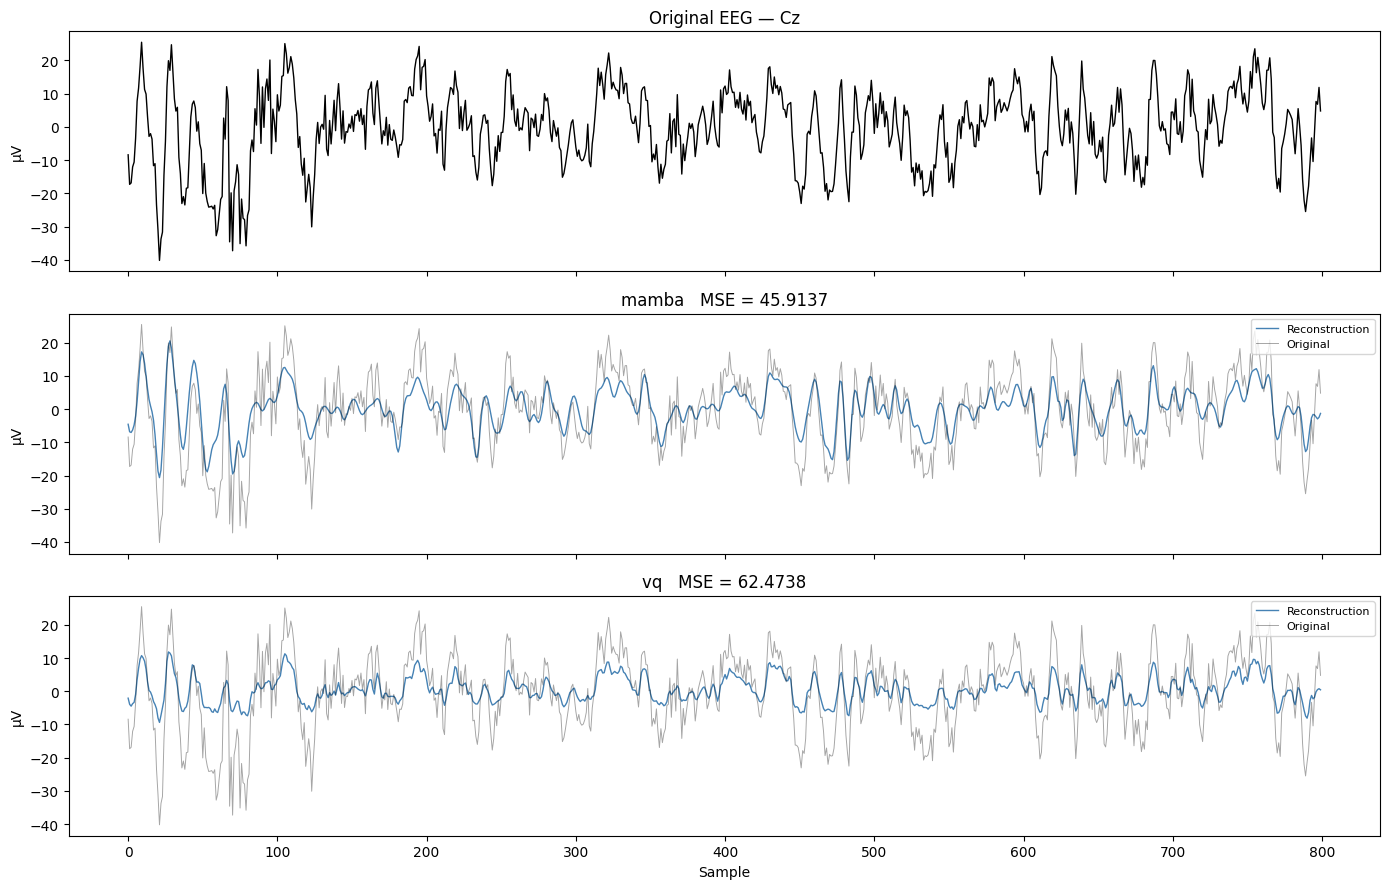

In [94]:
CH_IDX = 4                        # Cz in the 19-ch standard layout
x_one  = x_batch[:1].float()

recon_models = {k: v for k, v in models.items() if k != 'jepa'}
fig, axes = plt.subplots(len(recon_models) + 1, 1, figsize=(14, 3 * (len(recon_models) + 1)), sharex=True)

axes[0].plot(x_one[0, CH_IDX].numpy(), color='k', lw=1)
axes[0].set_title('Original EEG — Cz'); axes[0].set_ylabel('µV')

for ax, (name, model) in zip(axes[1:], recon_models.items()):
    with torch.no_grad():
        rec = model.reconstruct(x_one.to(DEVICE)).cpu()
    mse = (rec[0, CH_IDX] - x_one[0, CH_IDX]).pow(2).mean().item()
    ax.plot(rec[0, CH_IDX].numpy(),   color='steelblue', lw=1,   label='Reconstruction')
    ax.plot(x_one[0, CH_IDX].numpy(), color='k',         lw=0.7, alpha=0.35, label='Original')
    ax.set_title(f'{name}   MSE = {mse:.4f}'); ax.set_ylabel('µV')
    ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Sample')
plt.tight_layout()
Path('logs').mkdir(exist_ok=True)
plt.savefig('logs/reconstruction_comparison.png', dpi=150)
plt.show()

## 3b · Power Spectral Density comparison

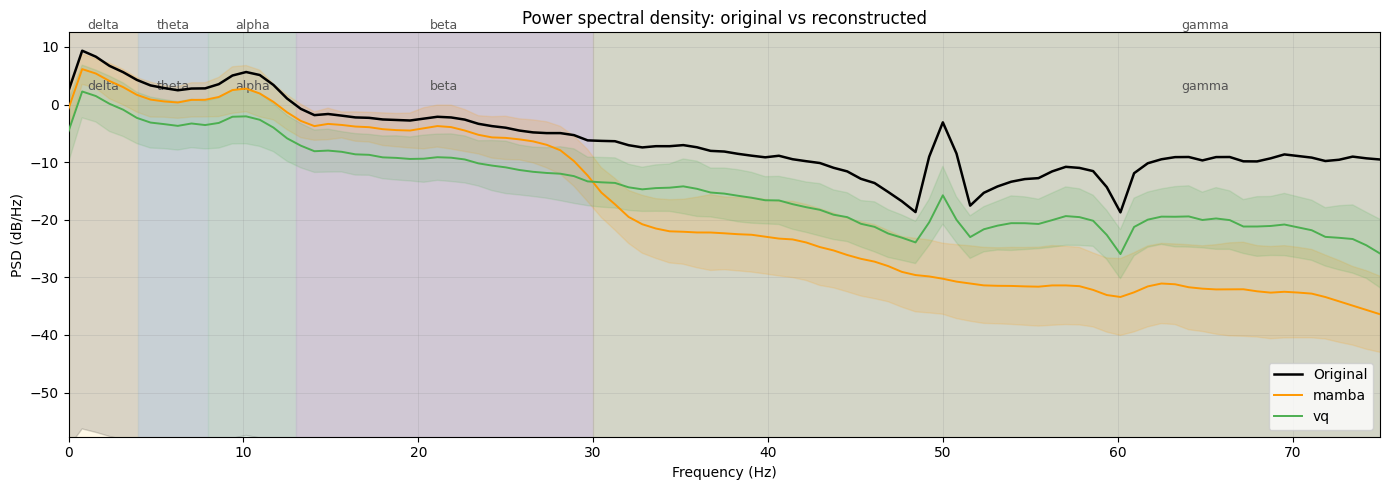

In [95]:
from scipy.signal import welch

# ── Frequency bands ───────────────────────────────────────────────────────────
BANDS = [
    ('delta', 0,   4,   '#FFF3CD', 0.45),
    ('theta', 4,   8,   '#D6EAF8', 0.45),
    ('alpha', 8,   13,  '#D5F5E3', 0.45),
    ('beta',  13,  30,  '#EBD5F5', 0.45),
    ('gamma', 30,  None,'#F0F4C3', 0.35),
]

def compute_psd(x_np):
    """x_np: (B, C, T)  →  freqs, mean_psd_dB (F,), std_psd_dB (F,)"""
    psds = []
    for b in range(x_np.shape[0]):
        for c in range(x_np.shape[1]):
            f, p = welch(x_np[b, c], fs=FS, nperseg=256)
            psds.append(p)
    psds = np.array(psds)                        # (B*C, F)
    mean_db = 10 * np.log10(psds.mean(axis=0) + 1e-12)
    std_db  = 10 * np.log10(psds + 1e-12).std(axis=0)
    return f, mean_db, std_db

# Compute PSD for original and all Phase 1 models on the full batch
x_np = x_batch.numpy()   # (B, 19, T)

psd_data = {'Original': compute_psd(x_np)}
for name, model in models.items():
    if name == 'jepa':
        continue
    with torch.no_grad():
        rec = model.reconstruct(x_batch.to(DEVICE)).cpu().numpy()
    psd_data[name] = compute_psd(rec)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

colors = {'Original': 'k', 'transformers': '#2196F3', 'mamba': '#FF9800', 'vq': '#4CAF50'}

# Band shading
f_ref = psd_data['Original'][0]
f_max = f_ref[-1]
for label, flo, fhi, color, alpha in BANDS:
    x0 = flo
    x1 = fhi if fhi is not None else f_max
    ax.axvspan(x0, x1, color=color, alpha=alpha, zorder=0)
    ax.text((x0 + x1) / 2, ax.get_ylim()[1] if ax.get_ylim()[1] != 1.0 else 2,
            label, ha='center', va='bottom', fontsize=9, color='#555555')

# PSD lines
for name, (f, mean_db, std_db) in psd_data.items():
    c = colors.get(name, 'grey')
    lw = 1.8 if name == 'Original' else 1.4
    ax.plot(f, mean_db, color=c, lw=lw, label=name, zorder=3)
    ax.fill_between(f, mean_db - std_db, mean_db + std_db, color=c, alpha=0.15, zorder=2)

# Re-draw band labels on top after ylim is set
ax.relim(); ax.autoscale_view()
ymax = ax.get_ylim()[1]
for label, flo, fhi, *_ in BANDS:
    x1 = fhi if fhi is not None else f_max
    ax.text((flo + x1) / 2, ymax, label, ha='center', va='bottom', fontsize=9, color='#555555')

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('PSD (dB/Hz)')
ax.set_title('Power spectral density: original vs reconstructed')
ax.set_xlim(0, min(75, f_max))
ax.legend(loc='lower right')
ax.grid(True, lw=0.4, alpha=0.4)
plt.tight_layout()
plt.savefig('logs/psd_comparison.png', dpi=150)
plt.show()

## 4 · Temporal consistency
For each sample find its *k* nearest neighbours in the latent space and measure  
what fraction share the same BCI2A class label.  
**Random baseline = 0.25** (4 classes). Higher → more semantically structured latent.

In [96]:
from sklearn.neighbors import NearestNeighbors

K = 10

all_z = {name: [] for name in models}
all_y = []
for x, y in loader:
    for name, model in models.items():
        all_z[name].append(encode(model, x, is_jepa=(name == 'jepa')))
    all_y.append(y)

all_y = torch.cat(all_y).numpy()
all_z = {name: torch.cat(zs).numpy() for name, zs in all_z.items()}
print(f'Encoded {len(all_y)} samples\n')

print(f'k-NN label consistency (k={K})   random baseline = {1/4:.3f}')
print('-' * 38)
results = {}
for name, Z in all_z.items():
    _, idx = NearestNeighbors(n_neighbors=K+1, metric='cosine', n_jobs=-1).fit(Z).kneighbors(Z)
    results[name] = (all_y[idx[:, 1:]] == all_y[:, None]).mean()
    print(f'  {name:<14}  {results[name]:.3f}')

Encoded 500 samples

k-NN label consistency (k=10)   random baseline = 0.250
--------------------------------------
  mamba           0.261
  vq              0.255
  jepa            0.250


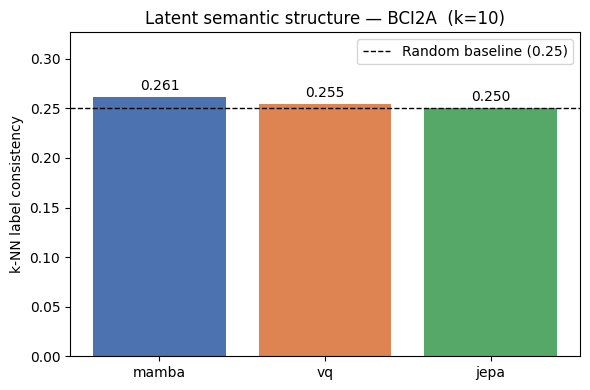

In [97]:
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(list(results.keys()), list(results.values()),
              color=['#4C72B0','#DD8452','#55A868','#C44E52'][:len(results)])
ax.axhline(0.25, color='k', ls='--', lw=1, label='Random baseline (0.25)')
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_ylim(0, max(results.values()) * 1.25)
ax.set_ylabel('k-NN label consistency')
ax.set_title(f'Latent semantic structure — BCI2A  (k={K})')
ax.legend()
plt.tight_layout()
plt.savefig('logs/temporal_consistency.png', dpi=150)
plt.show()

## 5 · UMAP

**Pourquoi le UMAP ne montre pas de clusters nets par classe ?**
C'est **attendu** pour un modèle Phase 1 (reconstruction).
La loss de reconstruction optimise la fidélité du signal, pas la séparation des classes.
Le latent capture *comment bien reconstruire*, pas *quelle classe motrice*.

Ce qu'on peut espérer observer :
- **Par sujet** : clusters nets → le latent capture les signatures individuelles EEG (inter-subject variability). C'est typiquement ce que produit un bon modèle de reconstruction.
- **Par classe** : clusters nets → le latent capture l'intention motrice. C'est l'objectif du Phase 2 (JEPA) + fine-tuning.

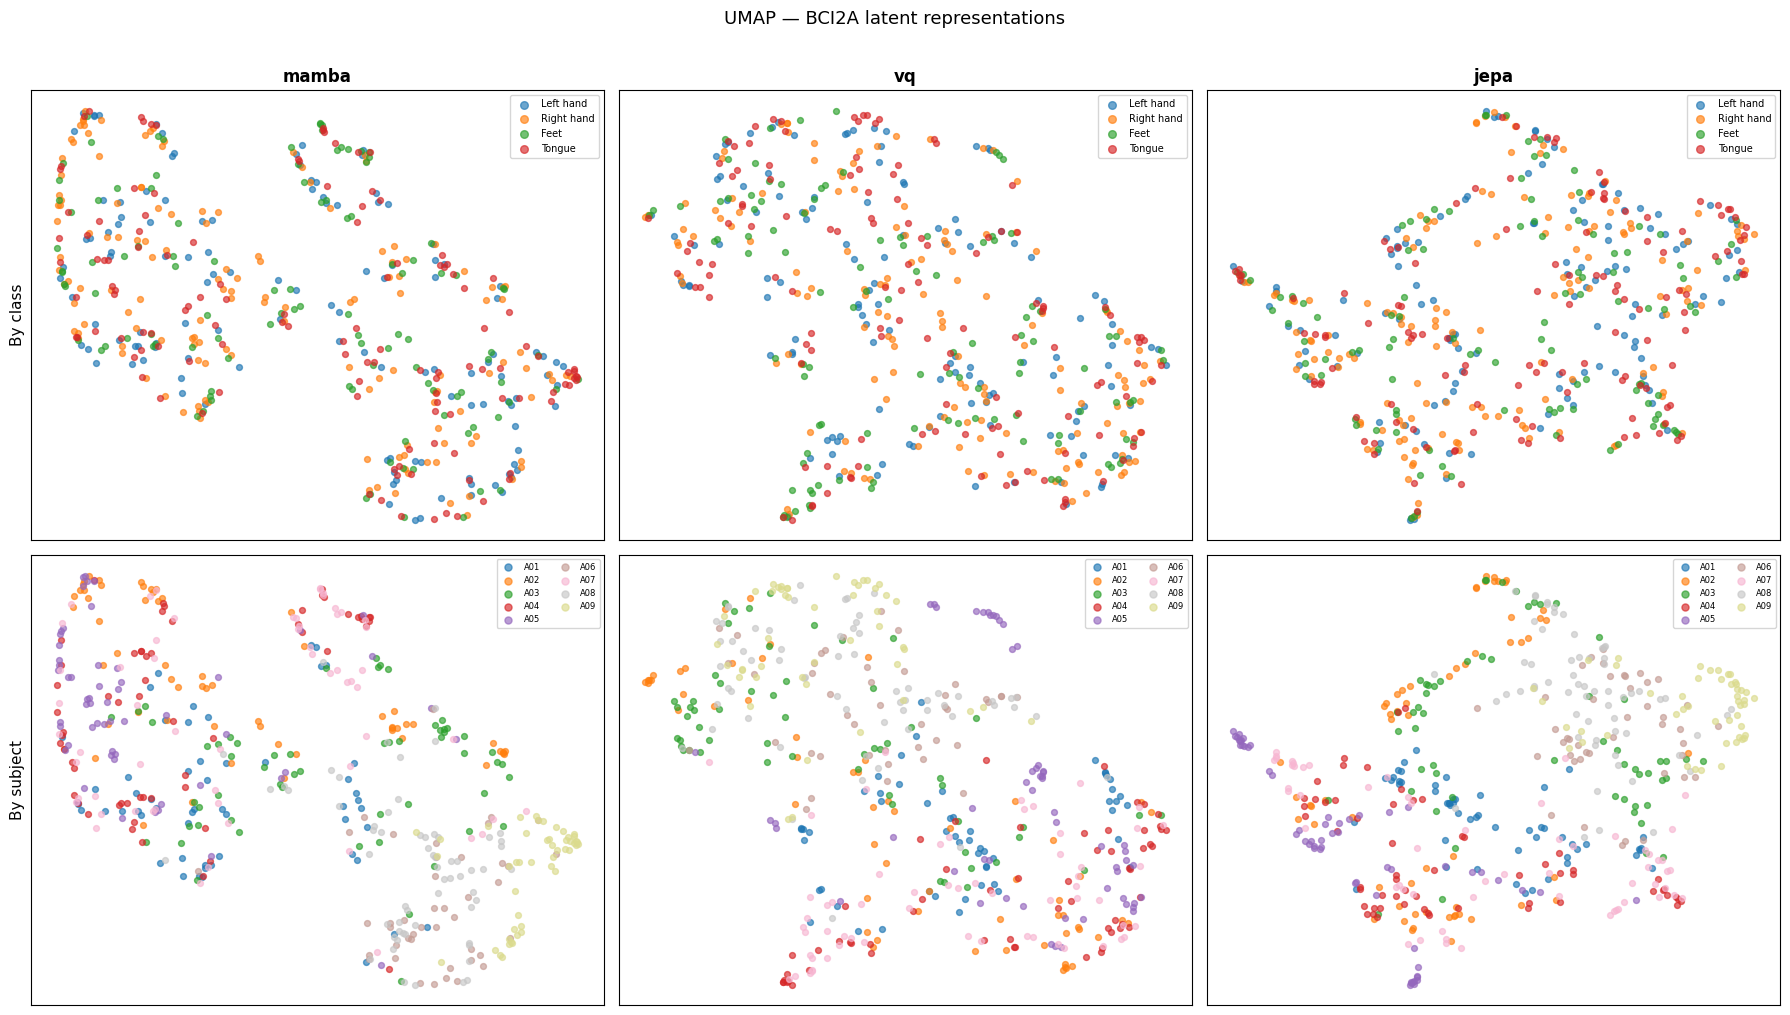

In [98]:
import umap

unique_subjects = sorted(set(sample_subjects))
n_subj   = len(unique_subjects)
subj2idx = {s: i for i, s in enumerate(unique_subjects)}
subj_int = np.array([subj2idx[s] for s in sample_subjects])

n_models      = len(all_z)
palette_class = plt.cm.tab10(np.arange(4) / 10)
palette_subj  = plt.cm.tab20(np.arange(n_subj) / max(n_subj, 1))

fig, axes = plt.subplots(2, n_models, figsize=(6 * n_models, 10))
if n_models == 1:
    axes = axes.reshape(2, 1)

for col, (name, Z) in enumerate(all_z.items()):
    Z2d = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42, verbose=False).fit_transform(Z)

    # Row 0 — by class
    ax = axes[0, col]
    for cls in range(4):
        mask = all_y == cls
        ax.scatter(Z2d[mask, 0], Z2d[mask, 1], c=[palette_class[cls]],
                   label=CLASS_NAMES[cls], alpha=0.65, s=18, rasterized=True)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.legend(fontsize=7, markerscale=1.3, loc='best')
    ax.set_xticks([]); ax.set_yticks([])
    if col == 0:
        ax.set_ylabel('By class', fontsize=11)

    # Row 1 — by subject
    ax = axes[1, col]
    for si, sid in enumerate(unique_subjects):
        mask = subj_int == si
        ax.scatter(Z2d[mask, 0], Z2d[mask, 1], c=[palette_subj[si]],
                   label=sid, alpha=0.65, s=18, rasterized=True)
    ax.legend(fontsize=6, markerscale=1.2, loc='best', ncol=2)
    ax.set_xticks([]); ax.set_yticks([])
    if col == 0:
        ax.set_ylabel('By subject', fontsize=11)

plt.suptitle('UMAP — BCI2A latent representations', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('logs/umap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()